## 1. Khai báo thư viện và đọc ảnh

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

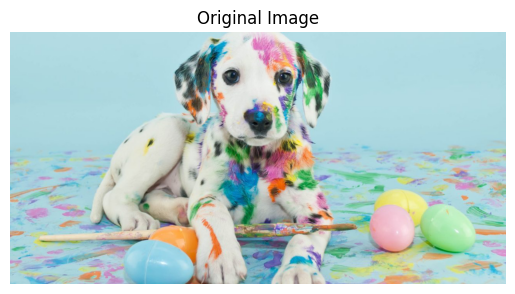

In [24]:
import cv2
import matplotlib.pyplot as vuong

# đọc ảnh
img = cv2.imread('dog.png')

# chuyển BGR -> RGB để hiển thị đúng màu
img = img[:,:,::-1]

vuong.imshow(img)
vuong.title("Original Image")
vuong.axis("off")

## 2️. FFT để phân tích ảnh trong miền tần số

In [25]:
import numpy as np
import cv2
from matplotlib import pyplot as vuong

# đọc ảnh grayscale
img = cv2.imread('dog.png',0)

# chuyển sang float32
img_float32 = np.float32(img)

# biến đổi Fourier
dft = cv2.dft(img_float32, flags = cv2.DFT_COMPLEX_OUTPUT)

# dịch chuyển tần số thấp vào giữa
dft_shift = np.fft.fftshift(dft)

# tính magnitude spectrum
magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]))

## 3️. Hiển thị ảnh và FFT

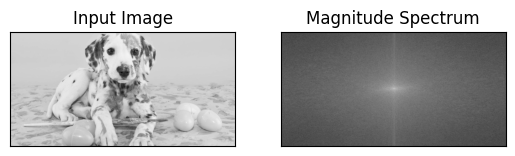

In [26]:
# Tạo subplot thứ 1 trong lưới 1 hàng 2 cột
vuong.subplot(121)
vuong.imshow(img, cmap='gray')
vuong.title('Input Image')

# Ẩn các giá trị trên trục x
vuong.xticks([])

# Ẩn các giá trị trên trục y
vuong.yticks([])

# Tạo subplot thứ 2 trong lưới 1 hàng 2 cột
vuong.subplot(122)

# Hiển thị phổ biên độ (Magnitude Spectrum) sau khi FFT
vuong.imshow(magnitude_spectrum, cmap='gray')

vuong.title('Magnitude Spectrum')
vuong.xticks([])
vuong.yticks([])

vuong.show()

## 4️. Phát hiện ảnh mờ bằng FFT + Difference of Gaussian

In [27]:
import matplotlib.pyplot as vuong  # thư viện hiển thị ảnh
import numpy as np               # thư viện xử lý mảng số

from skimage.data import gravel  # lấy ảnh mẫu gravel
from skimage.filters import difference_of_gaussians, window  # hàm lọc DoG và tạo cửa sổ

from scipy.fft import fftn, fftshift  # biến đổi Fourier và đưa tần số về giữa

## 5️. Xử lý FFT

In [28]:
image = gravel()  
# Lấy ảnh mẫu gravel từ skimage

wimage = image * window('hann', image.shape)  
# Nhân ảnh với cửa sổ Hann để giảm nhiễu khi tính FFT

filtered_image = difference_of_gaussians(image, 1, 12)  
# Lọc ảnh bằng Difference of Gaussians (lọc dải tần)

filtered_wimage = filtered_image * window('hann', image.shape)  
# Áp dụng cửa sổ Hann cho ảnh đã lọc

im_f_mag = fftshift(np.abs(fftn(wimage)))  
# Tính FFT của ảnh gốc và lấy biên độ phổ tần số

fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))  
# Tính FFT của ảnh sau khi lọc

## 6️. Hiển thị kết quả

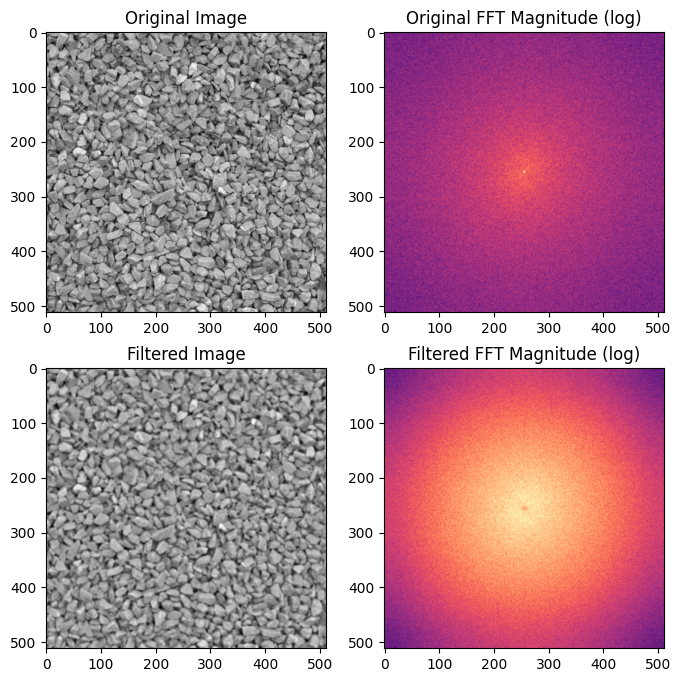

In [29]:
# Tạo figure gồm 2 hàng 2 cột để hiển thị ảnh
fig, ax = vuong.subplots(nrows=2, ncols=2, figsize=(8,8))

# Hiển thị ảnh gốc
ax[0,0].imshow(image, cmap='gray')
ax[0,0].set_title('Original Image')

# Hiển thị phổ tần số (FFT) của ảnh gốc
ax[0,1].imshow(np.log(im_f_mag), cmap='magma')
ax[0,1].set_title('Original FFT Magnitude (log)')

# Hiển thị ảnh sau khi lọc
ax[1,0].imshow(filtered_image, cmap='gray')
ax[1,0].set_title('Filtered Image')

# Hiển thị phổ tần số của ảnh sau khi lọc
ax[1,1].imshow(np.log(fim_f_mag), cmap='magma')
ax[1,1].set_title('Filtered FFT Magnitude (log)')

# Hiển thị tất cả hình
vuong.show()

## 7️. Harris Corner Detection

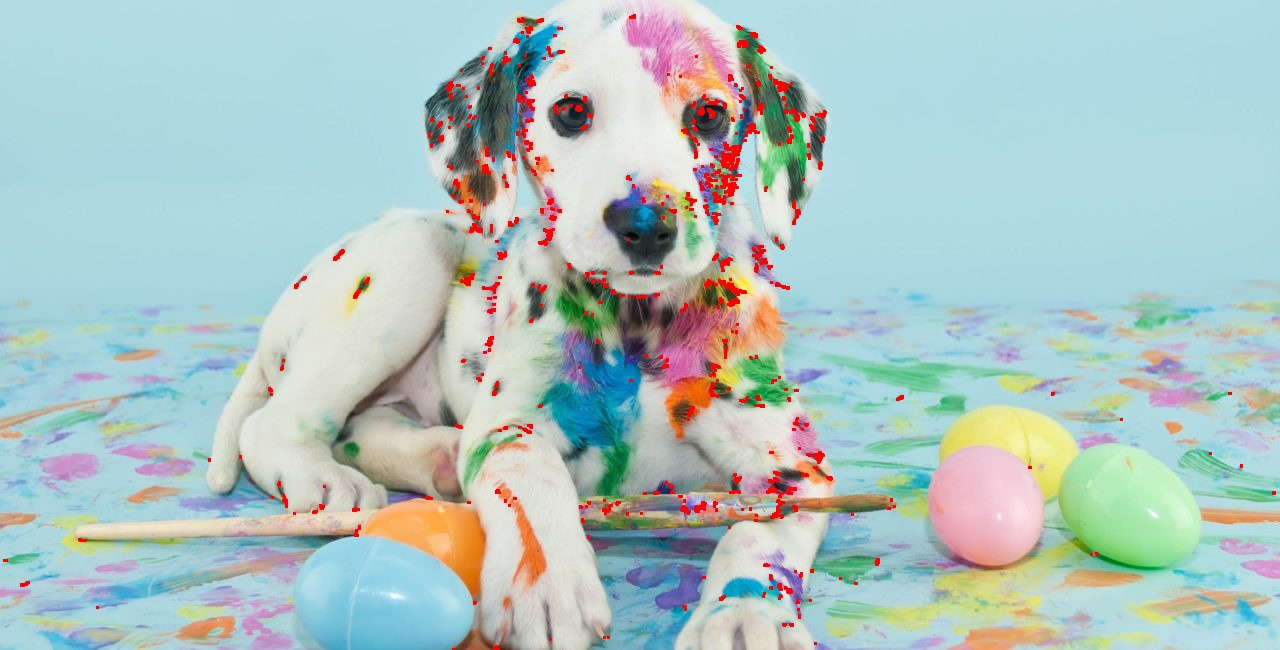

In [30]:
import cv2
import numpy as np
from IPython.display import Image

# Hàm phát hiện góc (corner) trong ảnh bằng Harris Corner Detection
def detect_corner(image_path, blockSize=2, ksize=3, k=0.04, threshold=0.01):

    # Đọc ảnh từ đường dẫn
    img = cv2.imread(image_path)

    # Chuyển ảnh sang grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Chuyển sang kiểu float32 để xử lý
    gray = np.float32(gray)

    # Áp dụng Harris Corner Detection
    dst = cv2.cornerHarris(gray, blockSize, ksize, k)

    # Làm nổi bật các góc
    dst = cv2.dilate(dst, None)

    # Đánh dấu các góc phát hiện được bằng màu đỏ
    img[dst > threshold * dst.max()] = [0,0,255]

    # Lưu ảnh kết quả
    cv2.imwrite('example.jpg', img)

    # Trả về đường dẫn ảnh kết quả
    return 'example.jpg'


# Gọi hàm phát hiện góc trên ảnh dog.png
out_path = detect_corner('dog.png', blockSize=2, ksize=5, k=0.04, threshold=0.005)

# Hiển thị ảnh kết quả
Image(out_path)

## 8️. Thử lại Harris Corner bằng matplotlib

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

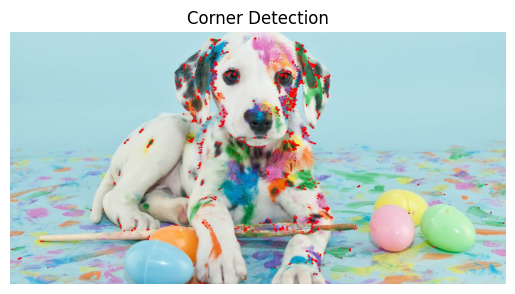

In [31]:
# Import các thư viện cần thiết
import numpy as np
import cv2
from matplotlib import pyplot as vuong

# Đọc ảnh đã được phát hiện góc
img = cv2.imread('example.jpg')

# Hiển thị ảnh (đổi từ BGR sang RGB để hiển thị đúng màu)
vuong.imshow(img[:,:,::-1])

# Đặt tiêu đề cho ảnh
vuong.title("Corner Detection")

# Tắt trục tọa độ
vuong.axis("off")

## 9️. Harris Corner cách 2

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

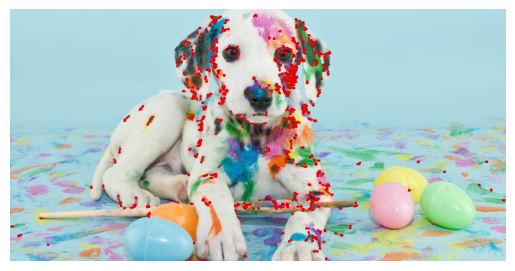

In [32]:
# Chuyển ảnh từ BGR sang ảnh xám (grayscale)
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# Chuyển kiểu dữ liệu sang float32 để dùng cho Harris
gray = np.float32(gray)

# Áp dụng thuật toán Harris Corner Detection
dst = cv2.cornerHarris(gray,2,3,0.04)

# Làm nổi bật các góc được phát hiện
dst = cv2.dilate(dst,None)

# Đánh dấu các góc trên ảnh bằng màu đỏ
img[dst>0.01*dst.max()] = [0,0,225]

# Hiển thị ảnh (đổi BGR -> RGB để matplotlib hiển thị đúng màu)
vuong.imshow(img[:,:,::-1])

# Tắt trục tọa độ
vuong.axis("off")